# 2a Escola de IA e Computação do CBPF (17-21/Ago/2026)
## Curso de Astrofísica Computacional
## Aula 2: Medidas de redshifts fotométricos de galáxias com aprendizado de máquina
## 2.a) Preparação dos dados

## Imports

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from astropy import units as u
from astropy.coordinates import SkyCoord

## Dados

### Sobre os dados


Nesta atividade, usaremos um conjunto de dados previamente combinado e parcialmente tratado, composto por catálogos que foram disponibilizados publicamente pelos seus levantamentos de origem. Estes dados foram obtidos a partir de dois métodos observacionais diferentes: a fotometria e a espectroscopia. 

As grandezas físicas que vamos utilizar no exemplo de aplicação de métodos de aprendizagem de máquina são as magnitudes aparentes e seus respectivos erros, cumprindo o papel de atributos observáveis (ou _features_) que usaremos para treinar o modelo de aprendizagem de máquina, e o _redshift_ (z), no papel de alvo a ser estimado (ou _target_). 

#### Magnitude aparente 

A magnitude é uma medida adimensional baseada em escala logaritmica associada à quantidade de energia luminosa que viaja a partir de uma fonte celeste e atinge o sensor do telescópio. A magnitude possui uma escala invertida ao brilho. Objetos mais brilhantes tem magnitudes menores. A magnitude absoluta quantifica o brilho intrínseco de um objeto e a magnitude aparente (a que conseguimos medir diretamente), é influenciada pela distância do objeto ao observador. 

#### Redshift 

O _redshift_ (z) é o desvio para o vermelho causado pelo efeito doppler cosmológico, que pode ser medido diretamente e utilizado para estimar distâncias de objetos extragalácticos.  

### Levantamentos fotométricos 


Os dados fotométricos são oriundos do [Dark Energy Survey (DES)](https://www.darkenergysurvey.org/), um levantamento fotométrico em 5 bandas do óptico ao infravermelho (_grizY_) que tem como principal objetivo a determinação da equação de estado da energia escura. O DES observou ~700 milhões de objetos detectados em ~5000 graus quadrados no hemisfério sul durante 6 anos. Os artigos com os principais resultados da análise dos dados dos seis primeiros anos de observação estão disponíveis [nesta página](https://www.darkenergysurvey.org/des-y6-cosmology-results-papers/).

<img align="center" src=https://www.darkenergysurvey.org/wp-content/uploads/2026/01/figintro-1024x500.png  width=750 style="padding: 20px"> <br> 
Figura: Footprint Data Release 2 (fonte: [www.darkenergysurvey.org](https://www.darkenergysurvey.org/wp-content/uploads/2026/01/figintro-1024x500.png)).  

O [segundo _data release_ (DR2)](https://des.ncsa.illinois.edu/releases/dr2), já contendo os dados dos seis anos de observação, está disponível para o público e pode ser acessado pelo [LIneA Science Server](https://scienceserver.linea.org.br) **INCLUIR DESCRIÇÃO DO LIneA e do JupyterHub.**

Os dados que vamos utilizar já foram extraídos das imagens do céu, pré-processados e disponibilizados de forma tabular no banco de dados. Os atributos observáveis (ou _features_) que usaremos para treinar o modelo de aprendizagem de máquina serão as magnitudes* aparentes nas 5 bandas _grizY_ e seus respectivos erros.


### Levantamentos espectroscópicos 


Para treinar os algoritmos de aprendizado supervisionado de máquina, precisamos fornecer medidas conhecidas (ou _labels_) da variável que estamos tentando calcular, neste caso, de _redshift_, de um subconjunto dos dados. Para isto, vamos utilizar dados obtidos de levantamentos espectroscópicos (spec-z) que, devido a sua enorme precisão quando comparada à fotometria, são considerados como valores "verdadeiros", ou seja, com erros nulos. 

As medidas de spec-z que vamos utilizar estão disponíveis em um catálogo, já associado aos dados fotométricos do DES, que foi produzido como parte da contribuição do LIneA para o projeto. A equipe de cientistas de dados do LIneA fez a curadoria das medidas de spec-z dos principais levantamentos disponíveis até o último ano de observações do DES (28 levantamentos) e montou um catálogo único de spec-zs, com dados limpos e homogeneizados. Esses dados foram associados às galáxias do DES através das posições em coordenadas equatoriais (R.A. e Dec.) através da técnica conhecida como _spatial cross-matching_. Este catálogo foi utilizado para alimentar os conjuntos de treinamento utilizados na produção de medidas de redshift fotométrico (photo-z) que estão sendo utilizadas nos artigos de cosmologia em preparação.  

<img align="center" src=https://dev.linea.org.br/~julia/specz_spatial_dist.png  width=500 style="padding: 20px"><img align="center" src=https://dev.linea.org.br/~julia/specz_matched_spatial_dist.png width=500 style="padding: 20px">  

Na figura acima observamos a distribuição espacial heterogênea resultante da combinação de várias fontes de dados espectroscópicos da literatura. No segundo mapa, vemos em destaque as medidas de spec-z que caem dentro da regição observada pelo DES (_footprint_). A caracterização completa desta amostra está disponível na [área de contribuição dos usuários](https://github.com/linea-it/jupyterhub-tutorial/blob/main/users-notebooks/spectroscopic-redshifts.ipynb), no mesmo repositório dos tutoriais do LIneA JupyterHub. 

A tabela abaixo traz a descrição das colunas que vamos utilizar neste _notebook_. 

|Coluna | Descrição |
|---|---|
|RA | Abreviação de _Right Ascension_, coordenada celeste equatorial no sistema J2000 (unidade: graus)|
|DEC | Abreviação de _Declination_, coordenada celeste equatorial no sistema J2000 (unidade: graus)   |
|MAG_AUTO_{G,R,I,Z,Y}_DERED | Medida de magnitude aparente corrigida do avermelhamento da Galáxia (adimensional) |
|MAGERR_AUTO_{G,R,I,Z,Y}    | Incerteza na medida de magnitude aparente (adimensional) |
|z | Medida de _redshift_ espectroscópico |
|survey | Nome do levantamento espectroscópico que realizou a medida de _redshift_ |



### Acesso aos dados

Para simplificar a tarefa de aquisição dos dados &mdash; que envolveria o login na plataforma, a compreensão do método de cross-matching e a construção de uma query SQL para obter os dados &mdash; este repositório já contém um arquivo em formato `parquet` com os dados pré-selecionados.

In [9]:
# Replace with wget command later
filepath = "../../data/des_dr2/public_pz_training_set.pq" # O arquivo está no formato 'parquet'/
df = pd.read_parquet(filepath)

### Exercício 1: Use funcionalidades básicas da biblioteca pandas para verificar o formato e o conteúdo da tabela de dados

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 592493 entries, 0 to 592492
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   coadd_object_id   592493 non-null  int64  
 1   ra                592493 non-null  float64
 2   dec               592493 non-null  float64
 3   z                 592493 non-null  float64
 4   err_z             592493 non-null  float64
 5   flag_des          592493 non-null  int64  
 6   survey            592493 non-null  str    
 7   flag_survey       592493 non-null  float64
 8   mag_auto_g_dered  592493 non-null  float64
 9   mag_auto_r_dered  592493 non-null  float64
 10  mag_auto_i_dered  592493 non-null  float64
 11  mag_auto_z_dered  592493 non-null  float64
 12  mag_auto_y_dered  592493 non-null  float64
 13  magerr_auto_g     592493 non-null  float64
 14  magerr_auto_r     592493 non-null  float64
 15  magerr_auto_i     592493 non-null  float64
 16  magerr_auto_z     592493 non-nu

In [11]:
df.head()

,coadd_object_id,ra,dec,z,err_z,flag_des,survey,flag_survey,mag_auto_g_dered,mag_auto_r_dered,mag_auto_i_dered,mag_auto_z_dered,mag_auto_y_dered,magerr_auto_g,magerr_auto_r,magerr_auto_i,magerr_auto_z,magerr_auto_y
0,1011353819,352.677720,-41.760673,0.2143,99.0,4,2DF,4.0,18.490623,17.264482,16.840298,16.531605,16.396919,0.004156,0.002004,0.002048,0.002808,0.007311
1,1012577456,352.603841,-41.669178,0.0867,99.0,4,2DF,4.0,18.502615,18.069166,17.864685,17.740002,17.689028,0.002561,0.002389,0.002843,0.004955,0.013531
2,1012581210,352.783951,-41.707007,0.0937,99.0,4,2DF,4.0,19.023310,18.133617,17.750835,17.465248,17.351370,0.003100,0.001907,0.002012,0.003469,0.009423
3,1012565977,352.797599,-41.553470,0.1886,99.0,3,2DF,3.0,18.697731,17.617779,17.249151,16.962301,16.844101,0.004236,0.002269,0.002361,0.003703,0.009919
4,1012559214,352.703943,-41.483863,0.0425,99.0,4,2DF,4.0,18.547184,18.249432,18.208136,18.075872,18.044237,0.004910,0.004967,0.007760,0.014178,0.040168


**Perguntas que eu quero que os alunos se façam:**
- Por que a coluna `err_z` só possui valores `99.0`?
- O que querem dizer as colunas `flag_des` e `flag_survey`?
- O que quer dizer o nome `dered`?

### Exercício 2: Faça um gráfico da distribuição dos dados no céu. Depois selecione somente os levantamentos `VVDS`, `VIPERS` e `GAMA` e investigue a distribuição de cada um deles

_Obs: os alunos devem identificar que as coordenadas `RA` e `DEC` não vem no formato correto e qual mudança precisa ser feita para colocá-los na forma apropriada._

#### 2.a) Change coordinates as needed

In [12]:
coords = SkyCoord(ra=-df["ra"].to_numpy()*u.degree,
                  dec=df["dec"].to_numpy()*u.degree,
                  frame="icrs")

df["ra_mpl"] = coords.ra.wrap_at(180 * u.degree).radian
df["dec_mpl"] = coords.dec.radian

print(coords.ra[0])
print(df.ra_mpl[0])

7d19m20.208s
0.12779789475293002


#### 2.b) Make the plot

In [13]:
def make_mollweide_plot(ra, dec):
    fig = plt.figure(figsize=(8, 5))
    ax = fig.add_subplot(111, projection="mollweide")
    plt.plot(ra, dec, ".", markersize=0.3, alpha=1)
    org = 0
    tick_labels = np.array([150, 120, 90, 60, 30, 0, 330, 300, 270, 240, 210]).astype(int)
    tick_labels = np.remainder(tick_labels + 360 + org, 360)
    ax.set_xticklabels(tick_labels)
    ax.grid()

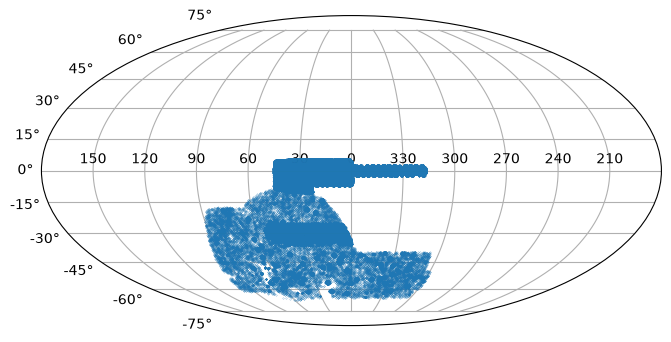

In [15]:
make_mollweide_plot(df["ra_mpl"], df["dec_mpl"])

#### 2.c) Refaça a figura somente com os levantamentos `VVDS`, `VIPERS` e `GAMA`

In [16]:
mask = (df["survey"].values == "VVDS") | (df["survey"].values == "VIPERS") | (df["survey"].values == "GAMA")
spec_sample = df[mask]

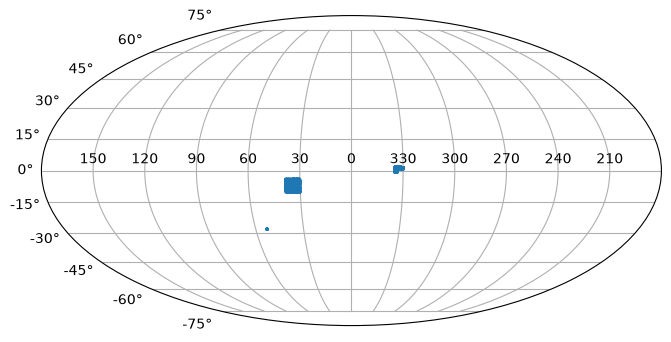

In [17]:
make_mollweide_plot(spec_sample["ra_mpl"], spec_sample["dec_mpl"])    

### Exercício 3: Analise as distribuições das galáxias nas variáveis pertinentes

#### 3.a) Faça uma limpeza básica dos dados

In [46]:
mag99_mask = ( (spec_sample["mag_auto_i_dered"] != 99.0) &
               (spec_sample["mag_auto_r_dered"] != 99.0) &
               (spec_sample["mag_auto_g_dered"] != 99.0) &
               (spec_sample["mag_auto_z_dered"] != 99.0)
)
spec_sample = spec_sample[mag99_mask]

#### 3.b) Investigue o número de galáxias por faixa de magnitude na banda $i$, total e para cada um dos levantamentos

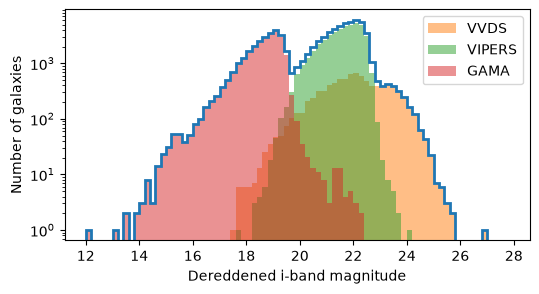

In [19]:
mag_i_bins = np.arange(12, 28, 0.2)
plt.figure(figsize=(6, 3))
_ = plt.hist(spec_sample["mag_auto_i_dered"], bins=mag_i_bins, histtype='step', lw=2)
for survey_name in ["VVDS", "VIPERS", "GAMA"]:
    subsample = spec_sample[spec_sample["survey"].values == survey_name]
    _ = plt.hist(subsample["mag_auto_i_dered"], bins=mag_i_bins, alpha=0.5, label=survey_name)
plt.xlabel("Dereddened i-band magnitude")
plt.ylabel("Number of galaxies")
plt.yscale("log")
plt.legend()

#### 3.c) Investigue o número de galáxias por faixa de redshift, total e para cada um dos levantamentos

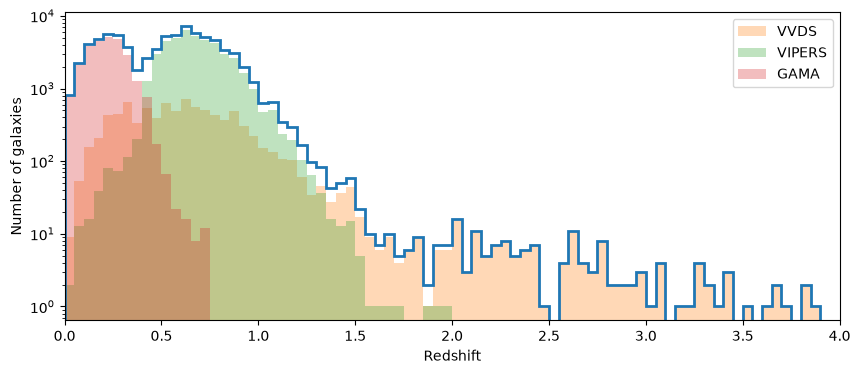

In [48]:
zbins = np.arange(0, 4.0, 0.05)
plt.figure(figsize=(10, 4))
_ = plt.hist(spec_sample["z"], bins=zbins, histtype='step', lw=2)
for survey_name in ["VVDS", "VIPERS", "GAMA"]:
    subsample = spec_sample[spec_sample["survey"] == survey_name]
    _ = plt.hist(subsample["z"], bins=zbins, alpha=0.3, label=survey_name)
plt.xlabel("Redshift")
plt.ylabel("Number of galaxies")
plt.legend()
plt.xlim(0, 4)
plt.yscale("log")

#### 3.d) Investigue a relação SNR vs mag_i separadamente para cada um dos levantamentos

### Exercício 4: Crie novas colunas para as cores e investigue diagramas cor-cor, cor-redshift e mag_i-redshift

In [50]:
spec_sample["g_minus_r"] = (spec_sample["mag_auto_g_dered"] -
                            spec_sample["mag_auto_r_dered"])
spec_sample["r_minus_i"] = (spec_sample["mag_auto_r_dered"] -
                            spec_sample["mag_auto_i_dered"])
spec_sample["i_minus_z"] = (spec_sample["mag_auto_i_dered"] -
                            spec_sample["mag_auto_z_dered"])
spec_sample["z_minus_y"] = (spec_sample["mag_auto_z_dered"] -
                            spec_sample["mag_auto_y_dered"])

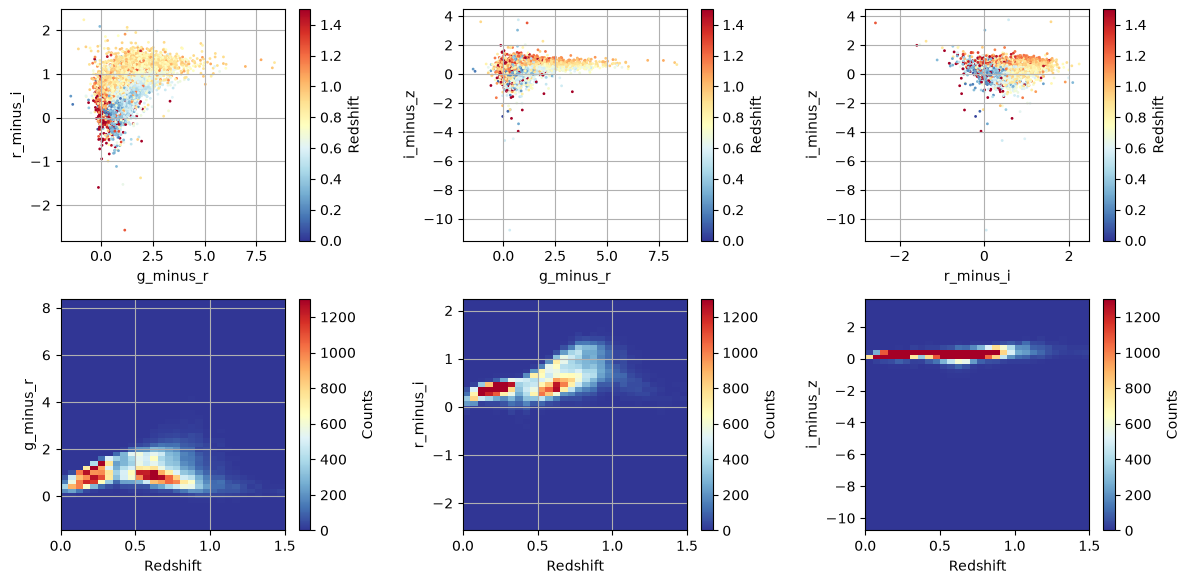

In [53]:
colors = ["g_minus_r", "r_minus_i", "i_minus_z"]
color_pairs = [("g_minus_r", "r_minus_i"),
               ("g_minus_r", "i_minus_z"),
               ("r_minus_i", "i_minus_z")]

fig, ax = plt.subplots(nrows=2, ncols=3, figsize = (12, 6))
for i, (color_x, color_y) in enumerate(color_pairs):
    im = ax[i // 3, i % 3].scatter(spec_sample[color_x],
                              spec_sample[color_y], c=spec_sample["z"], s=1, cmap="RdYlBu_r", vmin=0, vmax=1.5)
    ax[i // 3, i % 3].set_xlabel(color_x)
    ax[i // 3, i % 3].set_ylabel(color_y)
    ax[i // 3, i % 3].grid()
    fig.colorbar(im, ax=ax[i // 3, i % 3], label="Redshift")

for i, color in enumerate(colors):
    h = ax[1, i].hist2d(spec_sample["z"],
                        spec_sample[color],
                        bins=(zbins, 50),
                        cmap="RdYlBu_r", vmin=0, vmax=1300)
    ax[1, i].set_ylabel(color)
    ax[1, i].set_xlabel("Redshift")
    ax[1, i].set_xlim(0, 1.5)
    ax[1, i].grid()
    fig.colorbar(h[3], ax=ax[1, i], label="Counts")
plt.subplots_adjust()
plt.tight_layout()
plt.grid()

### Exercício 5: Baseado nas investigações dos exercícios 3 e 4, proponha cortes de qualidade 

In [54]:
mag_i = spec_sample["mag_auto_i_dered"].to_numpy()
mag_err_i = spec_sample["magerr_auto_i"].to_numpy()
gminusr = spec_sample["g_minus_r"].to_numpy()
rminusi = spec_sample["r_minus_i"].to_numpy()
iminusz = spec_sample["i_minus_z"].to_numpy()
clean = ( (mag_i < 23.0) &
          (mag_i > 17.0) &
          (mag_err_i < 0.1086) &
          (gminusr > 0) &
          (gminusr < 4) &
          (rminusi > 0) &
          (rminusi < 1.5) &
          (iminusz > -0.5) &
          (iminusz < 1.0)
        )

spec_sample_clean = spec_sample[clean]

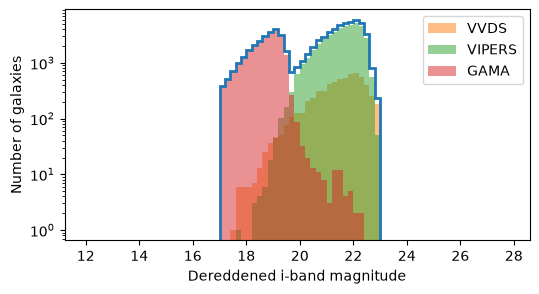

In [ ]:
mag_i_bins = np.arange(12, 28, 0.2)
plt.figure(figsize=(6, 3))
_ = plt.hist(spec_sample_clean["mag_auto_i_dered"], bins=mag_i_bins, histtype='step', lw=2)
for survey_name in ["VVDS", "VIPERS", "GAMA"]:
    subsample = spec_sample_clean[spec_sample_clean["survey"] == survey_name]
    _ = plt.hist(subsample["mag_auto_i_dered"], bins=mag_i_bins, alpha=0.5, label=survey_name)
plt.xlabel("Dereddened i-band magnitude")
plt.ylabel("Number of galaxies")
plt.yscale("log")
plt.legend()a

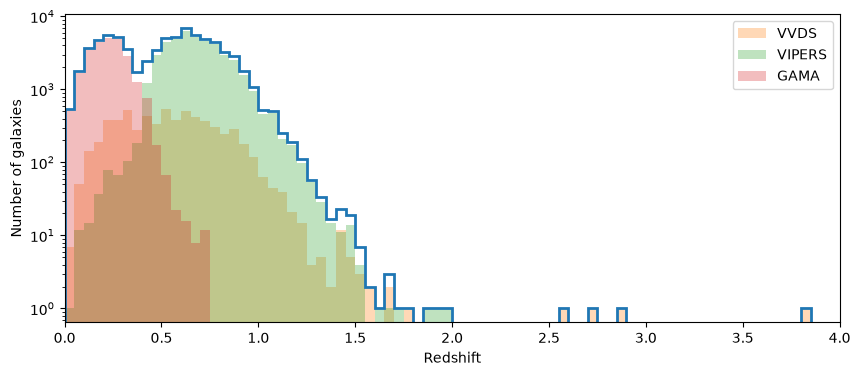

In [57]:
zbins = np.arange(0, 4.0, 0.05)
plt.figure(figsize=(10, 4))
_ = plt.hist(spec_sample_clean["z"], bins=zbins, histtype='step', lw=2)
for survey_name in ["VVDS", "VIPERS", "GAMA"]:
    subsample = spec_sample_clean[spec_sample_clean["survey"] == survey_name]
    _ = plt.hist(subsample["z"], bins=zbins, alpha=0.3, label=survey_name)
plt.xlabel("Redshift")
plt.ylabel("Number of galaxies")
plt.legend()
plt.xlim(0, 4)
plt.yscale("log")

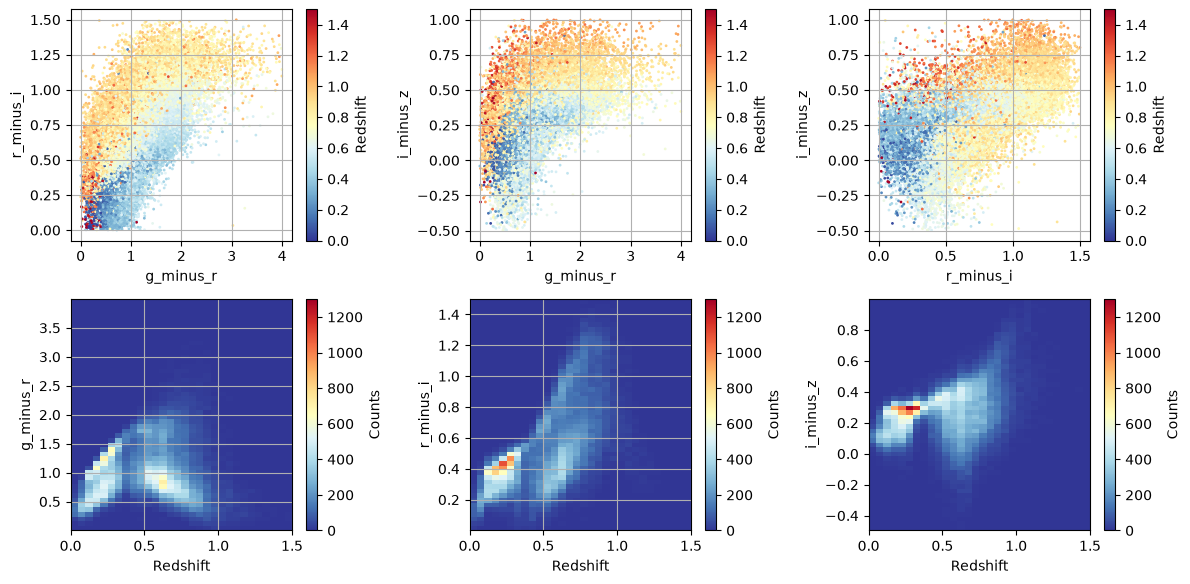

In [59]:
colors = ["g_minus_r", "r_minus_i", "i_minus_z"]
color_pairs = [("g_minus_r", "r_minus_i"),
               ("g_minus_r", "i_minus_z"),
               ("r_minus_i", "i_minus_z")]

fig, ax = plt.subplots(nrows=2, ncols=3, figsize = (12, 6))
for i, (color_x, color_y) in enumerate(color_pairs):
    im = ax[i // 3, i % 3].scatter(spec_sample_clean[color_x],
                              spec_sample_clean[color_y], c=spec_sample_clean["z"], s=1, cmap="RdYlBu_r", vmin=0, vmax=1.5)
    ax[i // 3, i % 3].set_xlabel(color_x)
    ax[i // 3, i % 3].set_ylabel(color_y)
    ax[i // 3, i % 3].grid()
    fig.colorbar(im, ax=ax[i // 3, i % 3], label="Redshift")

for i, color in enumerate(colors):
    h = ax[1, i].hist2d(spec_sample_clean["z"],
                        spec_sample_clean[color],
                        bins=(zbins, 50),
                        cmap="RdYlBu_r", vmin=0, vmax=1300)
    ax[1, i].set_ylabel(color)
    ax[1, i].set_xlabel("Redshift")
    ax[1, i].set_xlim(0, 1.5)
    ax[1, i].grid()
    fig.colorbar(h[3], ax=ax[1, i], label="Counts")
plt.subplots_adjust()
plt.tight_layout()
plt.grid()

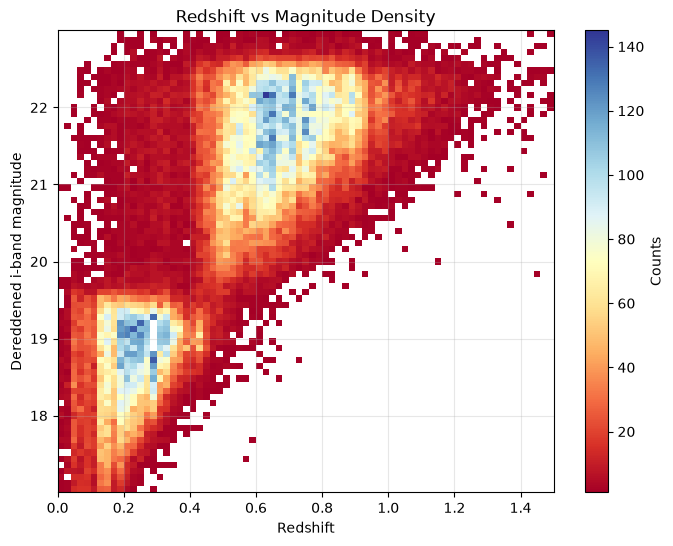

In [60]:
plt.figure(figsize=(8, 6))
h = plt.hist2d(spec_sample_clean["z"],
               spec_sample_clean["mag_auto_i_dered"], 
               bins=(np.arange(0, 1.6, 0.02), 75), 
               cmap="RdYlBu", 
               cmin=1, cmax=150)
plt.colorbar(h[3], label="Counts")
plt.xlim(0, 1.5)
plt.ylabel("Dereddened i-band magnitude")
plt.xlabel("Redshift")
plt.grid(alpha=0.3)
plt.title("Redshift vs Magnitude Density")
plt.show()

## Save data for photo-z measurements

In [64]:
spec_sample_clean.to_parquet("./data/des_dr2/des_dr2_pz_training_set_clean_vvds_vipers_gama.pq", index=False)